In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob 
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator,MonthLocator,DayLocator
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
# from mpl_toolkits.basemap import Basemap
# import cmocean as cm

month_fmt = DateFormatter('%b')
def m_fmt(tim, pos=None):
    return month_fmt(tim)[0]
import xrft as xt

import matplotlib.pyplot as plt
import numpy as np

import pyart
import matplotlib
import cmweather
import xarray as xr
import numpy as np
from colorspacious import cspace_convert

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean
from matplotlib import colors

/home/incois/sridevi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
mask=xr.open_dataset('roms_mask_final.nc').mask_rho
# mask

In [3]:
def detrend_data(data, time_dim='TIME', fill_value=999):
    valid_mask = data.isel({time_dim: 0}).notnull()
    data_filled = data.fillna(fill_value)
    detrended = xt.detrend(data_filled, dim=time_dim, detrend_type='linear').where(valid_mask)
    # std = detrended.std(dim='TIME')
    return detrended #std

In [4]:
# HP_ssp585_hist = xr.open_dataset('/home/incois/prasanna/ROMS_Projection/Codes/Ensemble_pH_Calculation/ROMS_Ensemble_pH_HP_surface.nc').HP.sel(TIME=slice('1980','2014')).where(mask)
# HP_ssp585_hist
HP_ssp585_hist = xr.open_dataset('BoB_pCO2_Sur_80_14.nc').pCO2.sel(LON_RHO577_841=slice(78,100),LAT_RHO379_689=slice(5,25))
HP_ssp585_hist
HP_ssp585_hist = HP_ssp585_hist.rename({
    "LON_RHO577_841": "LON_RHO",
    "LAT_RHO379_689": "LAT_RHO"
})
# HP_ssp585_hist

In [5]:
HP_ssp_585_FF = xr.open_dataset('pCO2_Ensemble_mean_FF.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(5,25))
HP_ssp_585_MF = xr.open_dataset('pCO2_Ensemble_mean_MF.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(5,25))
HP_ssp_585_NF = xr.open_dataset('pCO2_Ensemble_mean_NF.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(5,25))

In [6]:
# regions = ['BoB', 'NBoB', 'SBoB']
regions = ['NBoB', 'SBoB']

def region(data, region):
    regions_bounds = {
#         "BoB": {"lat": slice(5, 25), "lon": slice(78, 100)},
        "NBoB": {"lat": slice(15, 25), "lon": slice(78, 100)},
        "SBoB": {"lat": slice(5, 15), "lon": slice(78, 100)},
    }

    if region not in regions_bounds:
#         raise ValueError("Choose from: 'BoB', 'NBoB', 'SBoB")
        raise ValueError("Choose from: 'NBoB', 'SBoB")


    regional_data = data.sel(LAT_RHO=regions_bounds[region]['lat'],
                             LON_RHO=regions_bounds[region]['lon']).mean(dim=['LON_RHO','LAT_RHO'])
    return regional_data

# regions = ['BoB', 'NBoB', 'SBoB']

In [7]:
import numpy as np
import xarray as xr

def run_lengths_1d(arr):
    if arr.sum() == 0:
        return []

    arr = arr.astype(int)
    diff = np.diff(arr)

    starts = np.where(diff == 1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1

    if arr[0] == 1:
        starts = np.r_[0, starts]
    if arr[-1] == 1:
        ends = np.r_[ends, len(arr)]

    return ends - starts


def region_extreme_month_counts(
    HP_hist,
    HP_NF,
    HP_MF,
    HP_FF,
    region_name,
    detrend_data,
    scale=1,
    q=0.95,
    time_dim='TIME',
    which='count'
):
    """
    Extreme-month diagnostics for a region.

    Parameters
    ----------
    which : {'count', 'intensity', 'duration'}
        'count'     → number of extreme months
        'intensity' → cumulative exceedance above threshold
        'duration'  → mean duration of continuous extreme events (months)
    """

    # --- Historical (threshold) ---
    hist_reg = detrend_data(region(HP_hist * scale, region_name))
    threshold = hist_reg.quantile(q, dim=time_dim)

    # --- Other periods ---
    NF_reg = detrend_data(region(HP_NF * scale, region_name))
    MF_reg = detrend_data(region(HP_MF * scale, region_name))
    FF_reg = detrend_data(region(HP_FF * scale, region_name))

    if which == 'count':
        reducer = lambda x: x.where(x >= threshold).count(dim=time_dim)

        return {
            'hist': reducer(hist_reg).values,
            'NF'  : reducer(NF_reg).values,
            'MF'  : reducer(MF_reg).values,
            'FF'  : reducer(FF_reg).values,
        }

    elif which == 'intensity':
        reducer = lambda x: (x).where(x >= threshold).mean(dim=time_dim)

        return {
            'hist': reducer(hist_reg).values,
            'NF'  : reducer(NF_reg).values,
            'MF'  : reducer(MF_reg).values,
            'FF'  : reducer(FF_reg).values,
        }

    elif which == 'duration':

        def duration_metric(da):
            extreme = da >= threshold
            return xr.apply_ufunc(
                lambda x: np.mean(run_lengths_1d(x)) if len(run_lengths_1d(x)) > 1 else 0,
                extreme,
                input_core_dims=[[time_dim]],
                vectorize=True,
                dask='parallelized',
                output_dtypes=[float]
            )

        return {
            'hist': duration_metric(hist_reg).values,
            'NF'  : duration_metric(NF_reg).values,
            'MF'  : duration_metric(MF_reg).values,
            'FF'  : duration_metric(FF_reg).values,
        }

    else:
        raise ValueError("which must be 'count', 'intensity', or 'duration'")


In [8]:
import numpy as np

def compute_percent_change_stats(region_counts_models, models, regions,
                                 periods_future=('NF','MF','FF')):
    """
    Compute percent change relative to historical,
    then calculate multi-model mean and std.

    Returns
    -------
    plot_mean : array (n_regions, n_periods)
    plot_std  : array (n_regions, n_periods)
    mean_change : dict
    std_change  : dict
    """

    # -------- Percent change per model --------
    percent_change_models = {}

    for model in models:
        percent_change_models[model] = {}

        for reg in regions:

            hist_val = region_counts_models[model][reg]['hist']

            percent_change_models[model][reg] = {
                per: 100 * (
                    region_counts_models[model][reg][per] - hist_val
                ) / hist_val
                for per in periods_future
            }

    # -------- Multi-model mean & std --------
    mean_change = {}
    std_change  = {}

    for reg in regions:
        mean_change[reg] = {}
        std_change[reg]  = {}

        for per in periods_future:

            vals = np.array([
                percent_change_models[model][reg][per]
                for model in models
            ])

            mean_change[reg][per] = np.mean(vals)
            std_change[reg][per]  = np.std(vals)

    # -------- Convert to arrays for plotting --------
    plot_mean = np.array([
        [mean_change[reg][per] for per in periods_future]
        for reg in regions
    ])

    plot_std = np.array([
        [std_change[reg][per] for per in periods_future]
        for reg in regions
    ])

    return plot_mean, plot_std#, mean_change, std_change


In [9]:
region_counts_ROMS = {
    reg: region_extreme_month_counts(
        HP_ssp585_hist,
        HP_ssp_585_NF,
        HP_ssp_585_MF,
        HP_ssp_585_FF,
        reg,
        detrend_data,which='count'
    )
    for reg in regions
}

print(region_counts_ROMS)

import numpy as np

periods = ['hist','NF', 'MF', 'FF']

plot_data_ROMS_c = np.array([
    [(region_counts_ROMS[reg][per]-region_counts_ROMS[reg]['hist'])*100/region_counts_ROMS[reg]['hist'] for per in periods]
    for reg in regions
])
region_counts_ROMS_I = {
    reg: region_extreme_month_counts(
        HP_ssp585_hist,
        HP_ssp_585_NF,
        HP_ssp_585_MF,
        HP_ssp_585_FF,
        reg,
        detrend_data,which='intensity'
    )
    for reg in regions
}
print(region_counts_ROMS_I)


import numpy as np

plot_data_ROMS_i = np.array([
    [(region_counts_ROMS_I[reg][per]-region_counts_ROMS_I[reg]['hist'])*100/region_counts_ROMS_I[reg]['hist'] for per in periods]
    for reg in regions
])
region_counts_ROMS_E = {
    reg: region_extreme_month_counts(
        HP_ssp585_hist,
        HP_ssp_585_NF,
        HP_ssp_585_MF,
        HP_ssp_585_FF,
        reg,
        detrend_data,which='duration'
    )
    for reg in regions
}
print(region_counts_ROMS_E)

plot_data_ROMS_e = np.array([
    [(region_counts_ROMS_E[reg][per]-region_counts_ROMS_E[reg]['hist'])*100/region_counts_ROMS_E[reg]['hist'] for per in periods]
    for reg in regions
])

{'NBoB': {'hist': array(21), 'NF': array(35), 'MF': array(57), 'FF': array(77)}, 'SBoB': {'hist': array(21), 'NF': array(24), 'MF': array(50), 'FF': array(76)}}
{'NBoB': {'hist': array(40.31987303), 'NF': array(40.37653128), 'MF': array(46.5670578), 'FF': array(49.98191409)}, 'SBoB': {'hist': array(30.48908896), 'NF': array(31.05918959), 'MF': array(36.65728929), 'FF': array(45.9695072)}}
{'NBoB': {'hist': array(1.5), 'NF': array(1.52173913), 'MF': array(2.11111111), 'FF': array(2.56666667)}, 'SBoB': {'hist': array(1.10526316), 'NF': array(1.09090909), 'MF': array(1.66666667), 'FF': array(2.4516129)}}


In [10]:
####  CMIP Original Hypercapnia
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_CN1 = xr.open_dataset('CMIP_CNRM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_UK1 = xr.open_dataset('CMIP_UKESM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
# CMIP_GF,CMIP_CN,CMIP_UK,  

In [11]:
# # model have low resolution that obserrvations so, observations need to regrid
CMIP_UK = []
CMIP_UK = CMIP_UK1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)
CMIP_CN = []
CMIP_CN = CMIP_CN1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)

In [12]:
CMIP_CN['TIME'] = xr.cftime_range(
    start=str(CMIP_CN.TIME.values[0])[:10],
    periods=len(CMIP_CN.TIME),
    freq="MS"
)
# print(CMIP_CN.coords)
CMIP_CN = CMIP_CN.assign_coords(TIME=CMIP_GF.TIME)
CMIP_UK = CMIP_UK.assign_coords(TIME=CMIP_GF.TIME)
# print(CMIP_CN.coords)

CMIP_GF, CMIP_UK, CMIP_CN = xr.align(CMIP_GF, CMIP_UK, CMIP_CN)
common_mask = (~CMIP_GF.isnull()) & (~CMIP_UK.isnull()) & (~CMIP_CN.isnull())

CMIP_GF = CMIP_GF.where(common_mask)
CMIP_UK = CMIP_UK.where(common_mask)
CMIP_CN = CMIP_CN.where(common_mask)

CMIP_ens = xr.concat([CMIP_GF, CMIP_UK, CMIP_CN], dim='model').mean(dim='model')

CMIP_ensem_hist = CMIP_ens.sel(TIME=slice('1980', '2014'))
HP_ensem_CMIP = CMIP_ens.sel(TIME=slice('2071', '2100'))
HP_ensem_CMIP_MF = CMIP_ens.sel(TIME=slice('2041','2070'))
HP_ensem_CMIP_NF = CMIP_ens.sel(TIME=slice('2015','2040'))
# CMIP_ensem_hist

In [13]:
region_counts_CMIP = {
    reg: region_extreme_month_counts(
        CMIP_ensem_hist,
        HP_ensem_CMIP_NF,
        HP_ensem_CMIP_MF,
        HP_ensem_CMIP,
        reg,
        detrend_data,which='count'
    )
    for reg in regions
}
print(region_counts_CMIP)

plot_data_CMIP = np.array([
    [(region_counts_CMIP[reg][per]-region_counts_CMIP[reg]['hist'])*100/region_counts_CMIP[reg]['hist'] for per in periods]
    for reg in regions
])
region_counts_CMIP_I = {
    reg: region_extreme_month_counts(
        CMIP_ensem_hist,
        HP_ensem_CMIP_NF,
        HP_ensem_CMIP_MF,
        HP_ensem_CMIP,
        reg,
        detrend_data,which='intensity'
    )
    for reg in regions
}
print(region_counts_CMIP_I)

plot_data_CMIP_i = np.array([
    [(region_counts_CMIP_I[reg][per]-region_counts_CMIP_I[reg]['hist'])*100/region_counts_CMIP_I[reg]['hist'] for per in periods]
    for reg in regions
])
region_counts_CMIP_E = {
    reg: region_extreme_month_counts(
        CMIP_ensem_hist,
        HP_ensem_CMIP_NF,
        HP_ensem_CMIP_MF,
        HP_ensem_CMIP,
        reg,
        detrend_data,which='duration'
    )
    for reg in regions
}
print(region_counts_CMIP_E)

plot_data_CMIP_e = np.array([
    [(region_counts_CMIP_E[reg][per]-region_counts_CMIP_E[reg]['hist'])*100/region_counts_CMIP_E[reg]['hist'] for per in periods]
    for reg in regions
])

{'NBoB': {'hist': array(21), 'NF': array(34), 'MF': array(73), 'FF': array(122)}, 'SBoB': {'hist': array(21), 'NF': array(41), 'MF': array(74), 'FF': array(99)}}
{'NBoB': {'hist': array(34.12623596), 'NF': array(41.88561249), 'MF': array(44.2757225), 'FF': array(48.27652359)}, 'SBoB': {'hist': array(19.27254295), 'NF': array(21.50442123), 'MF': array(26.18544388), 'FF': array(28.73853683)}}
{'NBoB': {'hist': array(1.4), 'NF': array(1.61904762), 'MF': array(2.02777778), 'FF': array(2.77272727)}, 'SBoB': {'hist': array(1.23529412), 'NF': array(1.64), 'MF': array(1.94736842), 'FF': array(1.86792453)}}


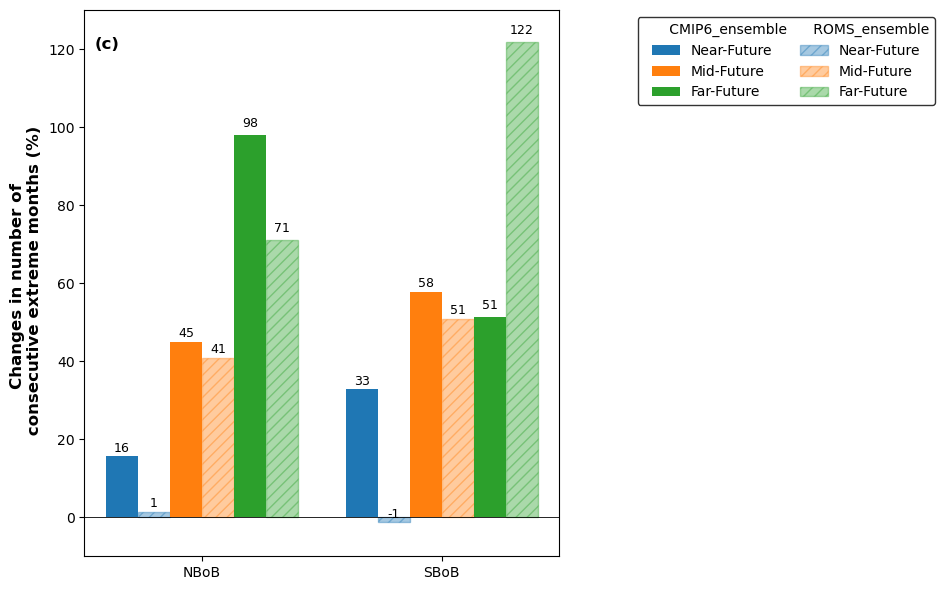

In [14]:
import numpy as np
import matplotlib.pyplot as plt

regions_plot = ['NBoB','SBoB']
idx = [regions.index(r) for r in regions_plot]

# Extract data
cmip = plot_data_CMIP_e[idx, 1:]
roms = plot_data_ROMS_e[idx, 1:]

x = np.arange(len(regions_plot))
width = 0.08

fig, ax = plt.subplots(figsize=(10,6))

periods_plot = ['NF','MF','FF']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Store legend handles
cmip_handles = []
roms_handles = []

for i, per in enumerate(periods_plot):
    x = np.arange(len(regions_plot)) * 0.6
    width = 0.08
    pos = x + i*width*2

    # CMIP bars (solid)
    bars1 = ax.bar(
        pos - width/2,
        cmip[:, i],
        width,
        color=colors[i]
    )

    # ROMS bars (hatched)
    bars2 = ax.bar(
        pos + width/2,
        roms[:, i],
        width,
        color=colors[i],
        alpha=0.4,
        hatch='///',
        edgecolor=colors[i]
    )

    cmip_handles.append(bars1[0])
    roms_handles.append(bars2[0])

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01*ax.get_ylim()[1],
                f'{height:.0f}',
                ha='center',
                va='bottom',
                fontsize=9,
            )
# X axis
ax.set_xticks(x + width*2)
ax.set_xticklabels(regions_plot)

# Y axis
ax.set_ylabel('Changes in number of \n consecutive extreme months (%)',fontweight='bold',fontsize=12)
ax.set_ylim(-10,130)

# Legend arranged as CMIP | ROMS
handles = cmip_handles + roms_handles
labels = ['Near-Future','Mid-Future','Far-Future','Near-Future','Mid-Future','Far-Future']
ax.axhline(y=0,color='black',linewidth=0.6)
legend = ax.legend(
    handles,
    labels,
    ncol=2,
    title='      CMIP6_ensemble      ROMS_ensemble',
    frameon=True,
    edgecolor='black',
    facecolor='white',
    loc='upper left',
    bbox_to_anchor=(1.15, 1)
)
ax.text(0.075, .95, '(c)', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
# plt.savefig('Ensemble_Extreme_consecutive_months_CMIP6_ROMS.png',dpi=400,facecolor='w', edgecolor='w',bbox_inches='tight') 
plt.tight_layout()
plt.show()

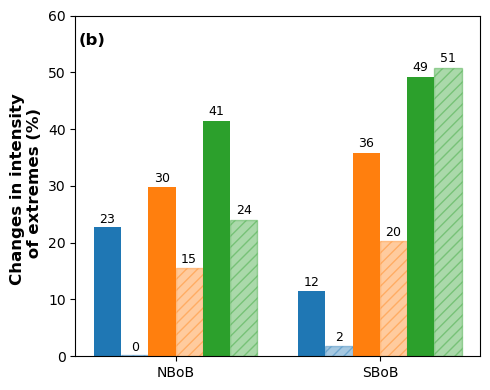

In [15]:
import numpy as np
import matplotlib.pyplot as plt

regions_plot = ['NBoB','SBoB']
idx = [regions.index(r) for r in regions_plot]

# Extract data
cmip = plot_data_CMIP_i[idx, 1:]
roms = plot_data_ROMS_i[idx, 1:]

x = np.arange(len(regions_plot))
width = 0.08

fig, ax = plt.subplots(figsize=(5,4))

periods_plot = ['NF','MF','FF']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Store legend handles
cmip_handles = []
roms_handles = []

for i, per in enumerate(periods_plot):
    x = np.arange(len(regions_plot))*0.6
    width = 0.08
    pos = x + i*width*2

    # CMIP bars (solid)
    bars1 = ax.bar(
        pos - width/2,
        cmip[:, i],
        width,
        color=colors[i]
    )

    # ROMS bars (hatched)
    bars2 = ax.bar(
        pos + width/2,
        roms[:, i],
        width,
        color=colors[i],
        alpha=0.4,
        hatch='///',
        edgecolor=colors[i]
    )

    cmip_handles.append(bars1[0])
    roms_handles.append(bars2[0])

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01*ax.get_ylim()[1],
                f'{height:.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )
# X axis
ax.set_xticks(x + width*2)
ax.set_xticklabels(regions_plot)

# Y axis
ax.set_ylabel('Changes in intensity \n of extremes (%)',fontweight='bold',fontsize=12)
ax.set_ylim(0,60)

# # Legend arranged as CMIP | ROMS
# handles = cmip_handles + roms_handles
# labels = ['NF','MF','FF','NF','MF','FF']

# ax.legend(
#     handles,
#     labels,
#     ncol=2,
#     title='CMIP         ROMS',
#     frameon=True,
#     edgecolor='black',
#     facecolor='white'
# )
ax.text(0.075, .95, '(b)', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
# plt.savefig('Ensemble_Extreme_intensisty_CMIP6_ROMS.png',dpi=400,facecolor='w', edgecolor='w',bbox_inches='tight') 
plt.tight_layout()
plt.show()

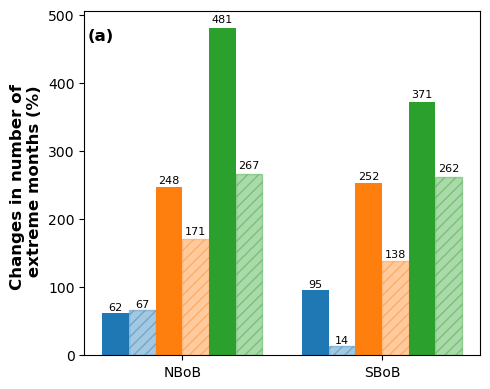

In [16]:
import matplotlib.pyplot as plt

regions_plot = ['NBoB','SBoB']
idx = [regions.index(r) for r in regions_plot]

# Extract data
cmip = plot_data_CMIP[idx, 1:]
roms = plot_data_ROMS_c[idx, 1:]



fig, ax = plt.subplots(figsize=(5,4))

periods_plot = ['NF','MF','FF']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Store legend handles
cmip_handles = []
roms_handles = []

for i, per in enumerate(periods_plot):
    x = np.arange(len(regions_plot))*0.6
    width = 0.08
    pos = x + i*width*2
    # CMIP bars (solid)
    bars1 = ax.bar(
        pos - width/2,
        cmip[:, i],
        width,
        color=colors[i]
    )

    # ROMS bars (hatched)
    bars2 = ax.bar(
        pos + width/2,
        roms[:, i],
        width,
        color=colors[i],
        alpha=0.4,
        hatch='///',
        edgecolor=colors[i]
    )

    cmip_handles.append(bars1[0])
    roms_handles.append(bars2[0])

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01*ax.get_ylim()[1],
                f'{height:.0f}',
                ha='center',
                va='bottom',
                fontsize=8
            )

# X axis
ax.set_xticks(x + width*2)
ax.set_xticklabels(regions_plot)

# Y axis
ax.set_ylabel('Changes in number of \n extreme months (%)',fontweight='bold',fontsize=12)
# ax.set_ylim(0,60)

# Legend arranged as CMIP | ROMS
# handles = cmip_handles + roms_handles
# labels = ['NF','MF','FF','NF','MF','FF']

# legend = ax.legend(
#     handles,
#     labels,
#     ncol=2,
#     title='      CMIP6_ensemble      ROMS_ensemble',
#     frameon=True,
#     edgecolor='black',
#     facecolor='white',
#     loc='upper left',
#     bbox_to_anchor=(1.2, 0.7)
# )

ax.text(0.075, .95, '(a)', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
# plt.savefig('Ensemble_Extreme_months_CMIP6_ROMS.png',dpi=400,facecolor='w', edgecolor='w',bbox_inches='tight') 
plt.tight_layout()
plt.show()